# P2 — Modelo descriptivo (segmentación de riesgo)

Segmentación de clientes por perfil de riesgo mediante clustering, a partir
de los datos limpios producidos en P1 (guardados en `datos/processed/`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from src.config import SEED, TARGET_COL, DATA_PROCESSED, POWERBI_DIR
from src.data import load_raw_training
from src.preprocessing import clean_data

np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## 1. Carga y limpieza de datos

Se reutiliza la limpieza documentada en P1 (`src/preprocessing.py`): tratamiento
de códigos 96/98, imputación de `MonthlyIncome`/`NumberOfDependents`/`age`, y
winsorización de `RevolvingUtilizationOfUnsecuredLines`/`DebtRatio`. Para fines
descriptivos se ajusta sobre el dataset completo (no aplica el concepto de
fuga de información hacia un conjunto de prueba, a diferencia de P3).

In [2]:
df = load_raw_training()
df = clean_data(df)
df.shape

(150000, 13)

## 2. Segmentación de clientes por perfil de riesgo

Se usa clustering (K-Means, k=4) sobre variables estandarizadas de
comportamiento crediticio (edad, utilización, deuda, ingreso, líneas abiertas,
atrasos históricos, inmuebles, dependientes). Se excluye `flag_codigo_error`
de las variables de clustering: al ser una bandera rara (0.18% de los casos),
domina la distancia euclidiana y el algoritmo simplemente aísla esas 269 filas
en su propio cluster — un hallazgo redundante con el de P1, no una segmentación
nueva.

In [3]:
cluster_features = [
    'age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines', 'NumberOfDependents',
]

Xs = StandardScaler().fit_transform(df[cluster_features])
kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
df['cluster'] = kmeans.fit_predict(Xs)

df['cluster'].value_counts().sort_index()

cluster
0    81519
1     7654
2    12074
3    48753
Name: count, dtype: int64

## 3. Patrones de morosidad por segmento

Perfil de cada cluster: tamaño, tasa de impago y promedios de las variables
que más lo explican.

In [4]:
segment_profile = df.groupby('cluster').agg(
    n=('cluster', 'size'),
    pct_total=('cluster', lambda s: len(s) / len(df) * 100),
    tasa_impago=(TARGET_COL, 'mean'),
    edad_prom=('age', 'mean'),
    utilizacion_prom=('RevolvingUtilizationOfUnsecuredLines', 'mean'),
    debtratio_prom=('DebtRatio', 'mean'),
    ingreso_prom=('MonthlyIncome', 'mean'),
    atraso90_prom=('NumberOfTimes90DaysLate', 'mean'),
    lineas_abiertas_prom=('NumberOfOpenCreditLinesAndLoans', 'mean'),
    inmuebles_prom=('NumberRealEstateLoansOrLines', 'mean'),
).round(2).sort_values('tasa_impago', ascending=False)

segment_profile

,n,pct_total,tasa_impago,edad_prom,utilizacion_prom,debtratio_prom,ingreso_prom,atraso90_prom,lineas_abiertas_prom,inmuebles_prom
cluster,,,,,,,,,,
1,7654,5.10,0.45,45.65,0.79,197.81,5315.56,1.32,6.82,0.72
3,48753,32.50,0.05,50.27,0.30,27.66,8829.04,0.02,12.09,1.78
0,81519,54.35,0.04,53.83,0.30,99.77,5273.65,0.03,6.20,0.49
2,12074,8.05,0.04,54.34,0.27,3021.96,5113.33,0.02,10.02,1.70


In [5]:
def nombrar_segmento(row):
    if row['tasa_impago'] > 0.20:
        return 'Alto riesgo'
    if row['debtratio_prom'] > 500:
        return 'Bajo riesgo (DebtRatio anómalo)'
    if row['ingreso_prom'] > 7000:
        return 'Bajo riesgo (patrimonio alto)'
    return 'Bajo riesgo (perfil modesto)'

segment_profile['nombre'] = segment_profile.apply(nombrar_segmento, axis=1)
cluster_to_nombre = segment_profile['nombre'].to_dict()
df['segmento'] = df['cluster'].map(cluster_to_nombre)

segment_profile

,n,pct_total,tasa_impago,edad_prom,utilizacion_prom,debtratio_prom,ingreso_prom,atraso90_prom,lineas_abiertas_prom,inmuebles_prom,nombre
cluster,,,,,,,,,,,
1,7654,5.10,0.45,45.65,0.79,197.81,5315.56,1.32,6.82,0.72,Alto riesgo
3,48753,32.50,0.05,50.27,0.30,27.66,8829.04,0.02,12.09,1.78,Bajo riesgo (patrimonio alto)
0,81519,54.35,0.04,53.83,0.30,99.77,5273.65,0.03,6.20,0.49,Bajo riesgo (perfil modesto)
2,12074,8.05,0.04,54.34,0.27,3021.96,5113.33,0.02,10.02,1.70,Bajo riesgo (DebtRatio anómalo)


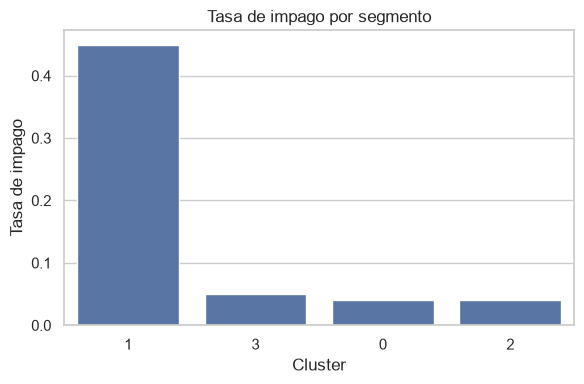

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
order = segment_profile.index
sns.barplot(x=order.astype(str), y=segment_profile['tasa_impago'], order=order.astype(str), ax=ax)
ax.set_xlabel('Cluster')
ax.set_ylabel('Tasa de impago')
ax.set_title('Tasa de impago por segmento')
plt.tight_layout()
plt.savefig('figures/p2_tasa_impago_por_cluster.png', dpi=150)
plt.show()

## 4. Bitácora de patrones hallados

1. **Segmento de alto riesgo, claramente separable (~5.1% de la cartera).**
   Un cluster de ~7,654 clientes concentra 45% de tasa de impago (vs. 6.68%
   global): son más jóvenes (46 años promedio vs. 50-54 en el resto), con
   utilización de crédito casi al límite (79% en promedio) y con historial de
   atrasos activo (1.3 veces de 90+ días y 1.8 veces de 30-59 días en
   promedio). Es el segmento prioritario para cualquier política de
   restricción de crédito (insumo directo para P4).
2. **Dos segmentos de bajo riesgo con perfiles económicos opuestos.** Un
   segmento (~32.5%) tiene alto patrimonio: más líneas de crédito (12.1),
   más propiedades inmobiliarias (1.78) e ingreso más alto (US$ 8,829 vs.
   ~US$ 5,200 en el resto) — clientes consolidados. Otro segmento (~54.3%,
   el más numeroso) tiene un perfil más modesto pero igual de bajo riesgo
   (4% de impago): esto indica que el riesgo no depende únicamente del nivel
   de ingreso o patrimonio, sino del comportamiento de pago.
3. **Un segmento revela que `DebtRatio` extremo no implica alto riesgo por sí
   solo (~8% de la cartera).** Este grupo tiene un `DebtRatio` promedio de
   3,022 (muy por encima del resto) pero una tasa de impago de solo 4%,
   igual que los segmentos "sanos". Esto confirma el hallazgo de P1: el
   `DebtRatio` se infla quirúrgicamente cuando el ingreso reportado es muy
   bajo, y no debe usarse sin corrección como proxy directo de riesgo real.
4. **La utilización de crédito y los atrasos recientes discriminan mejor que
   el ingreso o el patrimonio.** El segmento de alto riesgo no se distingue
   por tener menor ingreso (US$ 5,316, similar al segmento "modesto" de bajo
   riesgo), sino por su utilización y su historial de atrasos — variables que
   deben tener alto peso en el modelo predictivo de P3.

Estos patrones definen el conjunto de variables prioritarias para P3
(utilización, atrasos históricos, edad) y los segmentos que P4 debe tratar de
forma diferenciada en la política de aprobación/límite de crédito.

## 5. Exportar datasets (CSV)

Se exportan dos archivos CSV, reutilizables tanto por P3/P4 como por
Power BI (no requiere Power Query ni transformaciones adicionales, ya
vienen limpios y agregados):

- `datos/processed/credit_clean.csv`: dataset completo (150,000 clientes)
  con las variables limpias de P1 más `cluster` y `segmento`.
- `powerbi/segmentos.csv`: tabla agregada de los 4 segmentos (una fila por
  segmento), para tarjetas y gráficos de resumen en Power BI.

In [7]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED / 'credit_clean.csv', index=True, index_label='id_cliente')

POWERBI_DIR.mkdir(parents=True, exist_ok=True)
segment_profile.reset_index().to_csv(POWERBI_DIR / 'segmentos.csv', index=False)

print('Guardado:', DATA_PROCESSED / 'credit_clean.csv')
print('Guardado:', POWERBI_DIR / 'segmentos.csv')

Guardado: C:\Users\user\Desktop\Analitica\datos\processed\credit_clean.csv
Guardado: C:\Users\user\Desktop\Analitica\powerbi\segmentos.csv
